# 🎯 LỚP 1: PHÂN CỤM KHÁCH HÀNG ĐA CHIỀU (9 CHIỀU DỮ LIỆU)

**Câu chuyện kinh doanh:**
Phân cụm khách hàng dựa trên 3 trụ cột:
1. **Giao dịch (Transactional):** Recency, Frequency, Monetary, AOV.
2. **Tương tác (Engagement):** Total Sessions, Session Depth, Products Viewed.
3. **Hiệu suất (Efficiency):** Conversion Rate, Cart Abandon Rate.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from database import query_db
print("✅ Đã tải xong thư viện.")

✅ Đã tải xong thư viện.


## 1. Truy vấn RFM + Behavioral + Ratios (9 Features)

In [2]:
query_full = """
WITH user_rfm AS (
    SELECT
        user_id,
        MAX(created_at)              AS last_purchase_date,
        COUNT(DISTINCT order_id)     AS frequency,
        SUM(sale_price)              AS monetary
    FROM order_items
    WHERE status != 'Cancelled'
    GROUP BY user_id
    HAVING COUNT(DISTINCT order_id) >= 1
),
session_stats AS (
    SELECT 
        user_id,
        session_id,
        MAX(sequence_number) AS session_depth,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        COUNT(CASE WHEN event_type = 'product' THEN 1 ELSE NULL END) AS products_viewed
    FROM events
    WHERE user_id IS NOT NULL
    GROUP BY user_id, session_id
),
user_behavioral AS (
    SELECT
        user_id,
        COUNT(DISTINCT session_id)      AS total_sessions,
        AVG(session_depth)              AS avg_session_depth,
        AVG(products_viewed)            AS avg_products_viewed,
        -- Cart Abandon Rate: Tỷ lệ (Giỏ hàng - Mua hàng) / Giỏ hàng
        CASE 
            WHEN SUM(has_cart) > 0 THEN CAST(SUM(has_cart) - SUM(has_purchase) AS FLOAT) / SUM(has_cart)
            ELSE 0 
        END AS cart_abandon_rate
    FROM session_stats
    GROUP BY user_id
)
SELECT 
    r.user_id,
    r.last_purchase_date,
    r.frequency,
    r.monetary,
    -- Tính AOV (Average Order Value)
    CAST(r.monetary AS FLOAT) / r.frequency AS avg_order_value,
    b.total_sessions,
    b.avg_session_depth,
    b.avg_products_viewed,
    b.cart_abandon_rate,
    -- Tính Conversion Rate thực tế: Số đơn hàng / Số phiên truy cập
    CAST(r.frequency AS FLOAT) / b.total_sessions AS conversion_rate
FROM user_rfm r
INNER JOIN user_behavioral b ON r.user_id = b.user_id
"""

print("⏳ Đang truy vấn dữ liệu 9 chiều từ Database...")
df_full = query_db(query_full)

if df_full is not None:
    # Tính Recency
    reference_date = pd.Timestamp.now(tz='UTC')
    df_full['last_purchase_date'] = pd.to_datetime(df_full['last_purchase_date'], utc=True, format='mixed')
    df_full['recency'] = (reference_date - df_full['last_purchase_date']).dt.days
    
    feature_cols = [
        'recency', 'frequency', 'monetary', 'avg_order_value',
        'total_sessions', 'avg_session_depth', 'avg_products_viewed',
        'cart_abandon_rate', 'conversion_rate'
    ]
    
    # Xử lý ngoại lệ cho conversion_rate (nếu > 1 do dữ liệu lệch, ta giới hạn ở 1.0)
    df_full['conversion_rate'] = df_full['conversion_rate'].clip(upper=1.0)
    
    print(f"✅ Đã tải {len(df_full):,} khách hàng.")
    print(f"📊 Thống kê 9 chỉ số:")
    display(df_full[feature_cols].describe().round(2))

⏳ Đang truy vấn dữ liệu 9 chiều từ Database...
✅ Đã tải 57,422 khách hàng.
📊 Thống kê 9 chỉ số:


,recency,frequency,monetary,avg_order_value,total_sessions,avg_session_depth,avg_products_viewed,cart_abandon_rate,conversion_rate
count,57422.00,57422.00,57422.00,57422.00,57422.00,57422.00,57422.00,57422.0,57422.00
mean,1685.90,1.48,127.12,85.83,2.27,6.23,1.52,0.0,0.72
std,257.69,0.78,130.76,82.18,1.61,2.01,0.79,0.0,0.32
min,1417.00,1.00,0.02,0.02,1.00,5.00,1.00,0.0,0.08
25%,1480.00,1.00,39.99,34.47,1.00,5.00,1.00,0.0,0.50
50%,1601.00,1.00,84.00,61.50,2.00,5.00,1.00,0.0,1.00
75%,1821.00,2.00,170.00,109.53,3.00,7.00,2.00,0.0,1.00
max,2665.00,4.00,1753.32,1266.99,12.00,13.00,4.00,0.0,1.00


## 2. Phân cụm (K=4)

In [3]:
if df_full is not None:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_full[feature_cols])

    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_full['cluster'] = km.fit_predict(X_scaled)

    # Xếp hạng cụm theo Monetary
    monetary_rank = df_full.groupby('cluster')['monetary'].mean().sort_values().index.tolist()
    name_map = {
        monetary_rank[0]: 'Khách hàng Ngủ đông',
        monetary_rank[1]: 'Khách hàng Vãng lai',
        monetary_rank[2]: 'Khách hàng Tiềm năng',
        monetary_rank[3]: 'Khách hàng VIP'
    }
    df_full['segment'] = df_full['cluster'].map(name_map)

    color_map = {
        'Khách hàng Ngủ đông': '#95a5a6',
        'Khách hàng Vãng lai': '#3498db',
        'Khách hàng Tiềm năng': '#f39c12',
        'Khách hàng VIP':      '#e74c3c'
    }
    print("✅ Phân cụm thành công.")

✅ Phân cụm thành công.


## 3. Radar Chart (9 chiều)

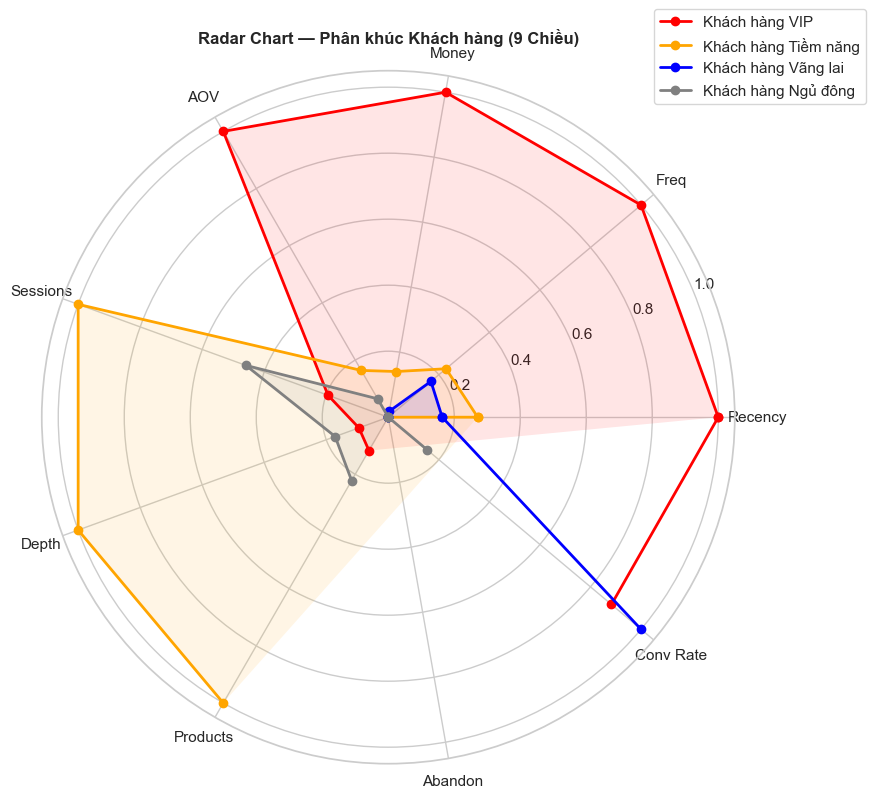

In [4]:
if df_full is not None:
    seg_profile = df_full.groupby('segment')[feature_cols].mean()
    normed = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())
    
    # Đảo ngược Recency & Cart Abandon (thấp mới là tốt)
    normed['recency'] = 1 - normed['recency']
    normed['cart_abandon_rate'] = 1 - normed['cart_abandon_rate']

    categories = ['Recency', 'Freq', 'Money', 'AOV', 'Sessions', 'Depth', 'Products', 'Abandon', 'Conv Rate']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    plt.figure(figsize=(9, 9))
    ax = plt.subplot(111, polar=True)
    
    colors = {
        'Khách hàng VIP': 'red', 
        'Khách hàng Tiềm năng': 'orange', 
        'Khách hàng Vãng lai': 'blue', 
        'Khách hàng Ngủ đông': 'gray'
    }
    
    for seg in ['Khách hàng VIP', 'Khách hàng Tiềm năng', 'Khách hàng Vãng lai', 'Khách hàng Ngủ đông']:
        values = normed.loc[seg].tolist() + [normed.loc[seg].iloc[0]]
        ax.plot(angles, values, 'o-', linewidth=2, label=seg, color=colors[seg])
        ax.fill(angles, values, alpha=0.1, color=colors[seg])
        
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    plt.title('Radar Chart — Phân khúc Khách hàng (9 Chiều)', fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

## 4. Xuất kết quả

In [5]:
if df_full is not None:
    df_full.to_csv('user_rfm_behavioral_clusters.csv', index=False)
    summary = df_full.groupby('segment').agg(
        count=('user_id', 'count'),
        monetary_avg=('monetary', 'mean'),
        conversion_avg=('conversion_rate', 'mean'),
        aov_avg=('avg_order_value', 'mean')
    ).round(2)
    display(summary)

,count,monetary_avg,conversion_avg,aov_avg
segment,,,,
Khách hàng Ngủ đông,16916,77.02,0.43,70.60
Khách hàng Tiềm năng,8289,114.13,0.32,81.38
Khách hàng VIP,9309,341.06,0.92,172.08
Khách hàng Vãng lai,22908,81.88,1.00,63.64
